# 11-3 모델 대신 이미지를 최적화하는 스타일 전이

본 노트북은 11-3절 본문 예제 [코드 11-14]~[코드 11-21]을 모아 위에서 아래로
실행해 본다. 모델 파라미터가 아닌 **이미지의 픽셀**을 옵티마이저로 직접
최적화하는 방식으로, 사전 학습된 VGG19 모델을 특징 추출기로 재활용해
콘텐츠와 스타일을 합성한다.

다루는 내용
- [코드 11-14] 그람 행렬 계산 함수
- [코드 11-15] 콘텐츠/스타일 이미지 로딩
- [코드 11-16]~[코드 11-18] `VGG19FeatureExtractor` 클래스
- [코드 11-17] 콘텐츠/스타일 특징 추출 계층 인덱스
- [코드 11-19] 콘텐츠 손실 + 스타일 손실 가중합 손실 함수
- [코드 11-20] 빈 이미지부터 시작하는 학습 루프
- [코드 11-21] 콘텐츠 이미지부터 시작하는 학습 루프
- 본문 비공개 항목: 가중치를 달리해 비교 ([그림 11-16])

이미지 파일은 저장소 `data/` 디렉터리의 것을 사용한다.
콘텐츠: `Tuebingen_Neckarfront.jpg`, 스타일: `starry_night.jpg`.[^vgg][^starry]

[^vgg]: https://pytorch.org/vision/stable/models.html — VGG19/ImageNet 가중치, BSD-3-Clause License.
[^starry]: 빈센트 반 고흐, 〈별이 빛나는 밤〉(1889) — 퍼블릭 도메인.


In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 11장 스타일 전이 예제는 torchvision (VGG19 가중치) 과 pillow 가 필요하다.
# !pip install -q matplotlib numpy pillow torch torchvision


In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [ ]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## [코드 11-14] 그람 행렬 계산 함수

(B, C, H, W) 특징 지도를 채널별 1차원 벡터로 펼친 뒤(view), 채널 벡터끼리
배치 행렬곱으로 내적해 (B, C, C) 그람 행렬을 만든다. 계층마다 채널 수와
공간 크기가 다르므로 `C * H * W`로 나눠 계층별 스타일 오차의 스케일을 맞춘다.


In [ ]:
###############################################################################
# 코드 11-14 - 그람 행렬 계산
###############################################################################
def gram_matrix(feature):
    B, C, H, W = feature.shape
    # 특징 지도를 채널 단위의 1차원 벡터로 펼침
    f = feature.view(B, C, H * W)
    # 채널 벡터 간 내적 = 채널별 특징의 동조 강도
    gram = torch.bmm(f, f.transpose(1, 2))      # (B, C, C)
    # 여러 계층의 스타일 오차를 비슷한 스케일로 맞추기 위한 정규화
    return gram / (C * H * W)


## [코드 11-15] 콘텐츠 / 스타일 이미지 로딩

VGG19가 ImageNet으로 학습되었으므로 동일한 정규화(평균 [0.485, 0.456, 0.406],
표준편차 [0.229, 0.224, 0.225])를 적용한다. 입력 이미지 크기는 편의상
256x256으로 통일한다. 본문은 `content_img_path`, `style_img_path`를 각자
환경에 맞춰 만들도록 안내하며, 여기서는 저장소 `data/` 경로를 사용한다.


In [ ]:
###############################################################################
# 코드 11-15 - 콘텐츠 / 스타일 이미지 로딩 함수
###############################################################################
IMG_SIZE = 256


def load_image(path, size=IMG_SIZE):
    img = Image.open(path).convert('RGB')
    # 데이터 변환 객체: 크기 변환 -> 텐서 변환 -> 정규화
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        # VGG19 학습에 사용된 ImageNet 정규화 값
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])
    return transform(img).unsqueeze(0).to(device)


content_img_path = '../../data/Tuebingen_Neckarfront.jpg'
style_img_path = '../../data/starry_night.jpg'
content_img = load_image(content_img_path)
style_img = load_image(style_img_path)
print(f'콘텐츠 이미지 텐서 shape: {tuple(content_img.shape)}')
print(f'스타일 이미지 텐서 shape: {tuple(style_img.shape)}')


콘텐츠 이미지 텐서 shape: (1, 3, 256, 256)
스타일 이미지 텐서 shape: (1, 3, 256, 256)


## [코드 11-16]~[코드 11-18] VGG19 특징 추출기

사전 학습된 VGG19의 합성곱 블록(`vgg.features`)을 사용해 콘텐츠·스타일 특징
지도를 추출한다. 학습 대상은 이미지 픽셀뿐이므로 VGG19의 모든 파라미터는
`requires_grad=False`로 고정한다. `forward()`는 지정한 계층의 출력 특징
지도를 콘텐츠/스타일별 딕셔너리로 모아 반환한다.


In [ ]:
###############################################################################
# 코드 11-16, 11-18 - VGG19 특징 추출기 클래스
###############################################################################
class VGG19FeatureExtractor(nn.Module):
    def __init__(self, content_layer_idxs, style_layer_idxs):
        super().__init__()
        # ImageNet 데이터셋으로 학습한 파라미터로 초기화한 VGG19 모델
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        # 콘텐츠 특징과 스타일 특징을 추출할 계층의 인덱스
        self.content_layer_idxs = content_layer_idxs
        self.style_layer_idxs = style_layer_idxs
        # 이미지를 최적화할 때 VGG19 파라미터가 함께 갱신되지 않도록 고정
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        content_features = {}
        style_features = {}
        # VGG19 합성곱 블록을 순차 통과시키며 지정된 계층의 특징 지도를 수집
        for idx, layer in enumerate(self.features):
            x = layer(x)
            if idx in self.content_layer_idxs:
                content_features[idx] = x
            if idx in self.style_layer_idxs:
                style_features[idx] = x
        return content_features, style_features


In [ ]:
###############################################################################
# 코드 11-17 - VGG19 모델에서 특징을 추출할 합성곱 계층의 인덱스
###############################################################################
# 콘텐츠 특징 추출 - 출력에 가까운 하나의 계층에서 추출
content_layer_idxs = [21]
# 스타일 특징 추출 - 골고루 배치된 여러 계층에서 추출
style_layer_idxs = [0, 5, 10, 19, 28]

feature_extractor = VGG19FeatureExtractor(
    content_layer_idxs, style_layer_idxs,
).to(device).eval()
print(f'콘텐츠 추출 계층: {content_layer_idxs}, '
      f'스타일 추출 계층: {style_layer_idxs}')


콘텐츠 추출 계층: [21], 스타일 추출 계층: [0, 5, 10, 19, 28]


## [코드 11-19] 콘텐츠 손실 + 스타일 손실 가중합

콘텐츠 손실은 특징 지도의 MSE, 스타일 손실은 그람 행렬의 MSE로 계산한 뒤
각각에 가중치를 곱해 더한다. 기본값은 `content_weight=1.0`,
`style_weight=1e5`로, 스타일 손실 가중치를 10만 배 크게 잡아야 두 손실항의
영향이 비슷해진다. 본문 함수는 `content_layer_idxs`, `style_layer_idxs`를
전역에서 참조하며, 여기서도 앞 셀에서 정의한 두 리스트를 사용한다.


In [ ]:
###############################################################################
# 코드 11-19 - 콘텐츠 손실과 스타일 손실의 가중합 손실 함수
###############################################################################
mse_loss = nn.MSELoss()


def criterion(generated_content_features, generated_style_features,
              content_image_features, style_image_features,
              content_weight=1.0, style_weight=1e5):
    # 콘텐츠 손실: 지정된 계층(들)의 특징 지도 MSE 합
    content_loss = sum(
        mse_loss(
            generated_content_features[idx], content_image_features[idx],
        )
        for idx in content_layer_idxs
    )
    # 스타일 손실: 지정된 계층들에서 그람 행렬 MSE 의 합
    style_loss = sum(
        mse_loss(
            gram_matrix(generated_style_features[idx]),
            gram_matrix(style_image_features[idx]),
        )
        for idx in style_layer_idxs
    )
    # 두 손실의 가중합을 손실로 사용 (개별 손실항은 학습 로그용으로 반환)
    total_loss = content_weight * content_loss + style_weight * style_loss
    return total_loss, content_loss, style_loss


## [코드 11-20] 빈 이미지부터 시작하는 스타일 전이

콘텐츠 이미지와 모양이 같은 0 텐서를 만든 뒤 `requires_grad_(True)`로 픽셀을
학습 대상으로 지정한다. 모델 파라미터 대신 이미지 텐서를 옵티마이저에
전달한다. 본문은 Adam 옵티마이저를 쓰지만 원 논문은 L-BFGS를 사용한다.
매 스텝 끝의 `clamp_(-3, 3)`은 정규화 범위를 크게 벗어나는 픽셀값을 잘라
안정성을 확보하는 안전 장치다.

기준 콘텐츠·스타일 특징은 한 번만 추출하고, 생성 이미지의 특징은 픽셀이
바뀌므로 매 스텝 새로 추출한다. 아래에서는 재사용을 위해 학습 루프를
`run_style_transfer` 함수로 감싼다.

스타일 전이는 에포크가 아니라 최적화 **스텝(반복)** 단위로 진행된다. 학습
로그·전체 시간·손실 곡선은 공통코드컨벤션 §7.6/§7.7에 따라
`common.EpochLogger`로 통일하되, 적응형 ~10행 출력 철학을 스텝 축에 그대로
적용한다(콘텐츠/스타일 두 손실을 분해해 출력). `log.summary()`가 전체 학습
시간을, `log.plot()`이 손실 곡선을 항상 표시한다. 여러 설정을 비교할 때는
설정별로 로거를 따로 둔다.


In [9]:
# 참고 - generated 가 leaf 텐서인지 검증 (옵티마이저가 픽셀을 갱신 가능)
test_gen = torch.zeros_like(content_img).requires_grad_(True)
print(f'is_leaf: {test_gen.is_leaf}, requires_grad: {test_gen.requires_grad}')
del test_gen


is_leaf: True, requires_grad: True


In [ ]:
###############################################################################
# 코드 11-20 - 생성 이미지를 모델처럼 학습하는 학습 루프
###############################################################################
def run_style_transfer(init_img, content_img, style_img, feature_extractor,
                       steps=1000, lr=0.03,
                       content_weight=1.0, style_weight=1e5):
    # 기준 콘텐츠와 기준 스타일 특징은 한 번만 추출
    with torch.no_grad():
        content_image_features, _ = feature_extractor(content_img)
        _, style_image_features = feature_extractor(style_img)

    # 0(또는 콘텐츠)으로 초기화한 생성 이미지 텐서를 학습 대상으로 지정
    generated = init_img.clone().detach().requires_grad_(True)
    # 모델 파라미터가 아닌 이미지 텐서를 최적화하는 옵티마이저
    optimizer = optim.Adam([generated], lr=lr)

    # 스타일 전이는 에포크가 아니라 최적화 스텝(반복) 단위다. 학습 로그·전체
    # 시간·손실 곡선은 공통코드컨벤션 §7.6/§7.7에 따라 common.EpochLogger 로
    # 통일하되, 적응형 ~10행 철학을 스텝 축에 그대로 적용한다(콘텐츠/스타일
    # 두 손실 분해 열).
    log = common.EpochLogger(
        steps,
        columns=('콘텐츠 손실', '스타일 손실'),
        formats=('{:.4f}', '{:.6f}'),
    )
    for step in range(1, steps + 1):
        optimizer.zero_grad()
        # 생성 이미지의 특징은 매 스텝마다 추출
        gen_content, gen_style = feature_extractor(generated)
        loss, content_loss, style_loss = criterion(
            gen_content, gen_style,
            content_image_features, style_image_features,
            content_weight, style_weight,
        )
        loss.backward()
        optimizer.step()
        # 정규화 범위를 크게 벗어나는 픽셀값을 잘라내 안정성 확보
        with torch.no_grad():
            generated.clamp_(-3, 3)
        log.row(step, content_loss.item(), style_loss.item())
    log.summary()
    return generated.detach(), log


## 참고 - 빈 이미지에서 출발한 세 가지 학습 ([그림 11-14] 대응)

본문 [그림 11-14]처럼 세 가지 가중치 조합으로 1,000 스텝 학습한 결과를
비교한다. (1) 기본값(콘텐츠+스타일), (2) 스타일만(`content_weight=0`),
(3) 콘텐츠만(`style_weight=0`). 설정별로 `EpochLogger`를 따로 두므로 세
표가 차례로 출력된다.


In [11]:
# 참고 - 빈 이미지부터 시작하는 세 가지 학습 (각 1,000 스텝)
blank_img = torch.zeros_like(content_img)
STEPS_BLANK = 1000

print('1) 기본값 (콘텐츠 + 스타일)')
gen_both, log_both = run_style_transfer(
    blank_img, content_img, style_img, feature_extractor,
    steps=STEPS_BLANK, lr=0.03, content_weight=1.0, style_weight=1e5,
)
print('\n2) 스타일만 (content_weight = 0)')
gen_style_only, _ = run_style_transfer(
    blank_img, content_img, style_img, feature_extractor,
    steps=STEPS_BLANK, lr=0.03, content_weight=0, style_weight=1e5,
)
print('\n3) 콘텐츠만 (style_weight = 0)')
gen_content_only, _ = run_style_transfer(
    blank_img, content_img, style_img, feature_extractor,
    steps=STEPS_BLANK, lr=0.03, content_weight=1.0, style_weight=0,
)


1) 기본값 (콘텐츠 + 스타일)
    epoch  콘텐츠 손실  스타일 손실     시간
   1/1000      11.0249     0.000277     0:00
 100/1000       2.5285     0.000025     0:02
 200/1000       1.9704     0.000018     0:03
 300/1000       1.7805     0.000016     0:04
 400/1000       1.6794     0.000015     0:05
 500/1000       1.6106     0.000014     0:06
 600/1000       1.5811     0.000014     0:07
 700/1000       1.5450     0.000014     0:08
 800/1000       1.5064     0.000014     0:09
 900/1000       1.4950     0.000013     0:11
1000/1000       1.4799     0.000013     0:12
--------------------------------------------
전체 학습 시간 0:12

2) 스타일만 (content_weight = 0)
    epoch  콘텐츠 손실  스타일 손실     시간
   1/1000      11.0249     0.000277     0:00
 100/1000      16.7142     0.000010     0:01
 200/1000      16.9604     0.000004     0:03
 300/1000      17.0544     0.000002     0:04
 400/1000      17.0992     0.000002     0:05
 500/1000      17.1341     0.000001     0:06
 600/1000      17.1459     0.000001     0:07
 700/1000      1

### 참고 - 결과 이미지 시각화

ImageNet 정규화를 역변환한 뒤 [0, 1] 범위로 클리핑해 화면에 표시한다.


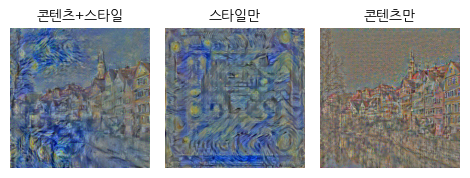

In [12]:
# 참고 - ImageNet 정규화 역변환 후 시각화 헬퍼
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def denormalize(img_tensor):
    img = img_tensor.detach().cpu()
    return (img * STD + MEAN).clamp(0, 1)


imgs = [
    denormalize(gen_both)[0],
    denormalize(gen_style_only)[0],
    denormalize(gen_content_only)[0],
]
descs = ['콘텐츠+스타일', '스타일만', '콘텐츠만']
viz.plot_images(imgs, descs, images_per_row=3, fig_title_size=10)


## 참고 - 학습 곡선

콘텐츠 손실과 스타일 손실의 변화 추이를 비교한다. 먼저 `log.plot()`으로
두 손실을 스텝 축에 그대로 그린다. 스타일 손실은 절대값이 매우 작아 한
축에서는 거의 평평하게 보이므로, 함께 보기 위해 3만 배 확대한 비교 그래프를
이어서 그린다.


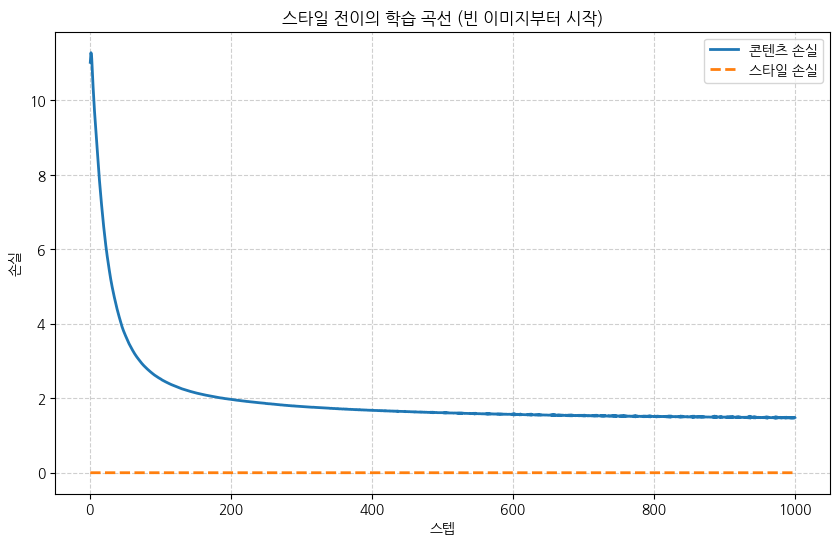

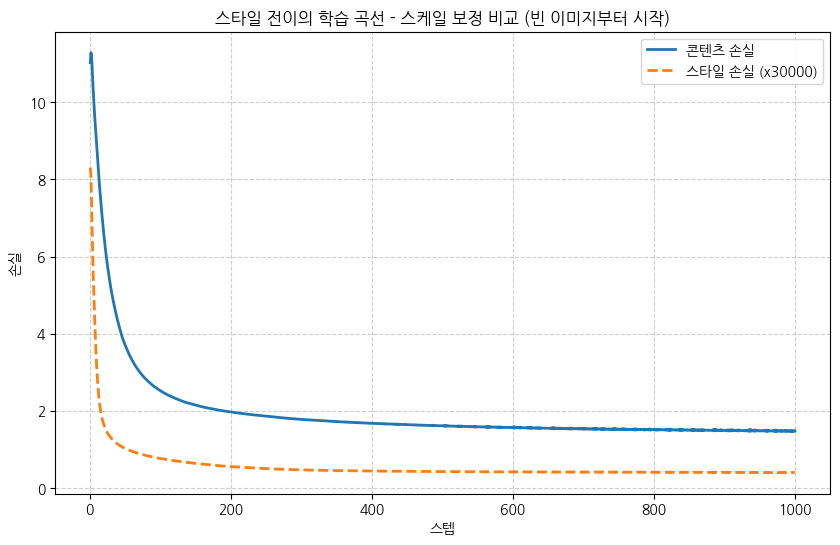

In [13]:
# 참고 - 콘텐츠 / 스타일 손실 학습 곡선
# EpochLogger 가 보관한 두 손실 이력으로 스텝 축 곡선을 항상 그린다.
log_both.plot(title='스타일 전이의 학습 곡선 (빈 이미지부터 시작)',
              x_label='스텝')
# 스타일 손실은 절대값이 매우 작으므로 함께 보기 위해 3만 배 확대해 비교한다.
style_scaled = [v * 30000 for v in log_both.history['스타일 손실']]
viz.plot_histories(
    {
        '콘텐츠 손실': log_both.history['콘텐츠 손실'],
        '스타일 손실 (x30000)': style_scaled,
    },
    title='스타일 전이의 학습 곡선 - 스케일 보정 비교 (빈 이미지부터 시작)',
    x_label='스텝',
    y_label='손실',
)


## [코드 11-21] 콘텐츠 이미지부터 시작하는 스타일 전이 ([그림 11-15] 대응)

빈 이미지가 아니라 콘텐츠 이미지에서 출발하면 콘텐츠 정보를 최대한 유지
하면서 스타일만 입히면 된다. `clone()`으로 복사하지 않으면 생성 이미지와
함께 콘텐츠 이미지도 바뀌므로 반드시 복사해 사용한다. 훨씬 적은 스텝
(500)로도 자연스러운 결과를 얻을 수 있다.


  epoch  콘텐츠 손실  스타일 손실     시간
  1/500       0.0000     0.000151     0:00
 50/500       1.5940     0.000019     0:01
100/500       1.4448     0.000017     0:01
150/500       1.3958     0.000016     0:02
200/500       1.3626     0.000015     0:02
250/500       1.3443     0.000015     0:03
300/500       1.3378     0.000014     0:03
350/500       1.3164     0.000014     0:04
400/500       1.3056     0.000014     0:05
450/500       1.3058     0.000014     0:05
500/500       1.2835     0.000014     0:06
------------------------------------------
전체 학습 시간 0:06


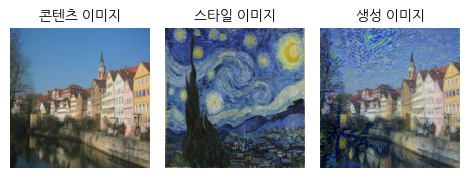

In [ ]:
###############################################################################
# 코드 11-21 - 콘텐츠 이미지부터 출발하는 스타일 전이
###############################################################################
STEPS_CONTENT = 500
# clone() 으로 복사하지 않으면 생성 이미지와 함께 콘텐츠 이미지도 변한다.
gen_from_content, log_from_content = run_style_transfer(
    content_img.clone(), content_img, style_img, feature_extractor,
    steps=STEPS_CONTENT, lr=0.03, content_weight=1.0, style_weight=1e5,
)

imgs = [
    denormalize(content_img)[0],
    denormalize(style_img)[0],
    denormalize(gen_from_content)[0],
]
descs = ['콘텐츠 이미지', '스타일 이미지', '생성 이미지']
viz.plot_images(imgs, descs, images_per_row=3, fig_title_size=10)


## 참고 - 스타일 가중치 비교 ([그림 11-16] 대응)

`style_weight`를 1e3, 1e5, 1e7로 바꾸어 스타일 전이의 강도를 비교한다.
모두 콘텐츠 이미지에서 500 스텝 출발하며, 설정별로 `EpochLogger`를 따로 둔다.



style_weight = 1000
  epoch  콘텐츠 손실  스타일 손실     시간
  1/500       0.0000     0.000151     0:00
 50/500       0.0521     0.000111     0:01
100/500       0.0281     0.000102     0:01
150/500       0.0231     0.000097     0:02
200/500       0.0201     0.000094     0:02
250/500       0.0183     0.000091     0:03
300/500       0.0193     0.000089     0:03
350/500       0.0190     0.000087     0:04
400/500       0.0170     0.000086     0:05
450/500       0.0174     0.000085     0:05
500/500       0.0180     0.000083     0:06
------------------------------------------
전체 학습 시간 0:06

style_weight = 100000
  epoch  콘텐츠 손실  스타일 손실     시간
  1/500       0.0000     0.000151     0:00
 50/500       1.5975     0.000019     0:01
100/500       1.4532     0.000016     0:01
150/500       1.3983     0.000016     0:02
200/500       1.3636     0.000015     0:03
250/500       1.3376     0.000015     0:03
300/500       1.3216     0.000014     0:04
350/500       1.3125     0.000014     0:04
400/500       1.3014

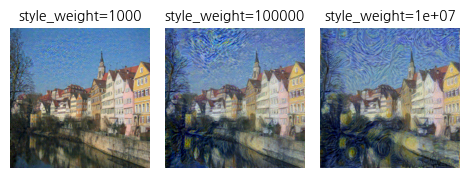

In [15]:
# 참고 - style_weight 1e3 / 1e5 / 1e7 비교 (설정별 EpochLogger)
style_weights = [1e3, 1e5, 1e7]
gen_by_weight = {}
for sw in style_weights:
    print(f'\nstyle_weight = {sw:g}')
    gen_by_weight[sw], _ = run_style_transfer(
        content_img.clone(), content_img, style_img, feature_extractor,
        steps=STEPS_CONTENT, lr=0.03, content_weight=1.0, style_weight=sw,
    )

imgs = [denormalize(gen_by_weight[sw])[0] for sw in style_weights]
descs = [f'style_weight={sw:g}' for sw in style_weights]
viz.plot_images(imgs, descs, images_per_row=3, fig_title_size=10)


본문 [그림 11-16]과 같이 `style_weight`가 커질수록 스타일 특징이 강하게
반영된 결과를 확인할 수 있다. 다만 1e7처럼 지나치게 큰 값은 콘텐츠 구조를
왜곡한다. 1e5 부근이 콘텐츠와 스타일의 균형이 가장 잘 잡힌 설정이다.
